In [80]:
import pandas as pd
import anndata as ad
import os
import scanpy as sc
from utils import *
from matplotlib_venn import venn3, venn2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
from gtfparse import read_gtf
import gseapy as gp
import decoupler as dc
from utils import *
from first_part import *

In [81]:
adata_tr = ad.read_h5ad("/Volumes/U32 Shadow/data/ATAC-seq/PPMI/PPMI_RNAseq_IR3_Analysis/adata_transcript.h5ad")
adata_tr.obs.groupby(['COHORT_DEFINITION', "subgroup"])['PATNO'].nunique()
condition = "subgroup"
method = 'pydeseq2_sex_adjusted_no_refit_bulk_rna'
adata_tr.obs.reset_index(drop=True, inplace=True)
adata_pd = adata_tr[adata_tr.obs['COHORT_DEFINITION'] =="Parkinson's Disease", :]
adata_pd.obs.reset_index(drop=True, inplace=True)
adata_pd.obs["celltype"] = "Bulk"
adata_pd.obs["brain_region"] = "blood"
adata_pd.obs["PatientID"] = adata_pd.obs["PATNO"].tolist()
adata_pd = adata_pd[adata_pd.obs["subgroup"].isin(["GBA1","LRRK2","SPOR"])]
adata_pd.obs["group"] = adata_pd.obs[condition].values
adata_pd.obs["condition"] = adata_pd.obs[condition].values
adata_pd.var["peakid"] = adata_pd.var_names
adata_pd
adata_pd.obs.groupby(['COHORT_DEFINITION', "subgroup"])['PATNO'].nunique()


/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/pandas/core/frame.py:6479: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  new_obj.index = new_index
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_90357/3544661037.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pd.obs["group"] = adata_pd.obs[condition].values


COHORT_DEFINITION    subgroup
Parkinson's Disease  GBA1         44
                     LRRK2       121
                     SPOR        207
Name: PATNO, dtype: int64

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_90357/1094734898.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pd_bl.obs["Sex"] = adata_pd_bl.obs["SEX"].replace({0:"Female", 1:"Male"})


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GBA1_Female vs. LRRK2_Female: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.963e-01 U_stat=1.754e+03
LRRK2_Female vs. SPOR_Female: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.243e-09 U_stat=2.456e+04
GBA1_Male vs. LRRK2_Male: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:9.279e-01 U_stat=1.901e+03
LRRK2_Male vs. SPOR_Male: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.121e-01 U_stat=2.995e+04
GBA1_Female vs. SPOR_Female: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.182e-01 U_stat=3.648e+03
GBA1_Male vs. SPOR_Male: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.655e-01 U_stat=8.918e+03
p-valu

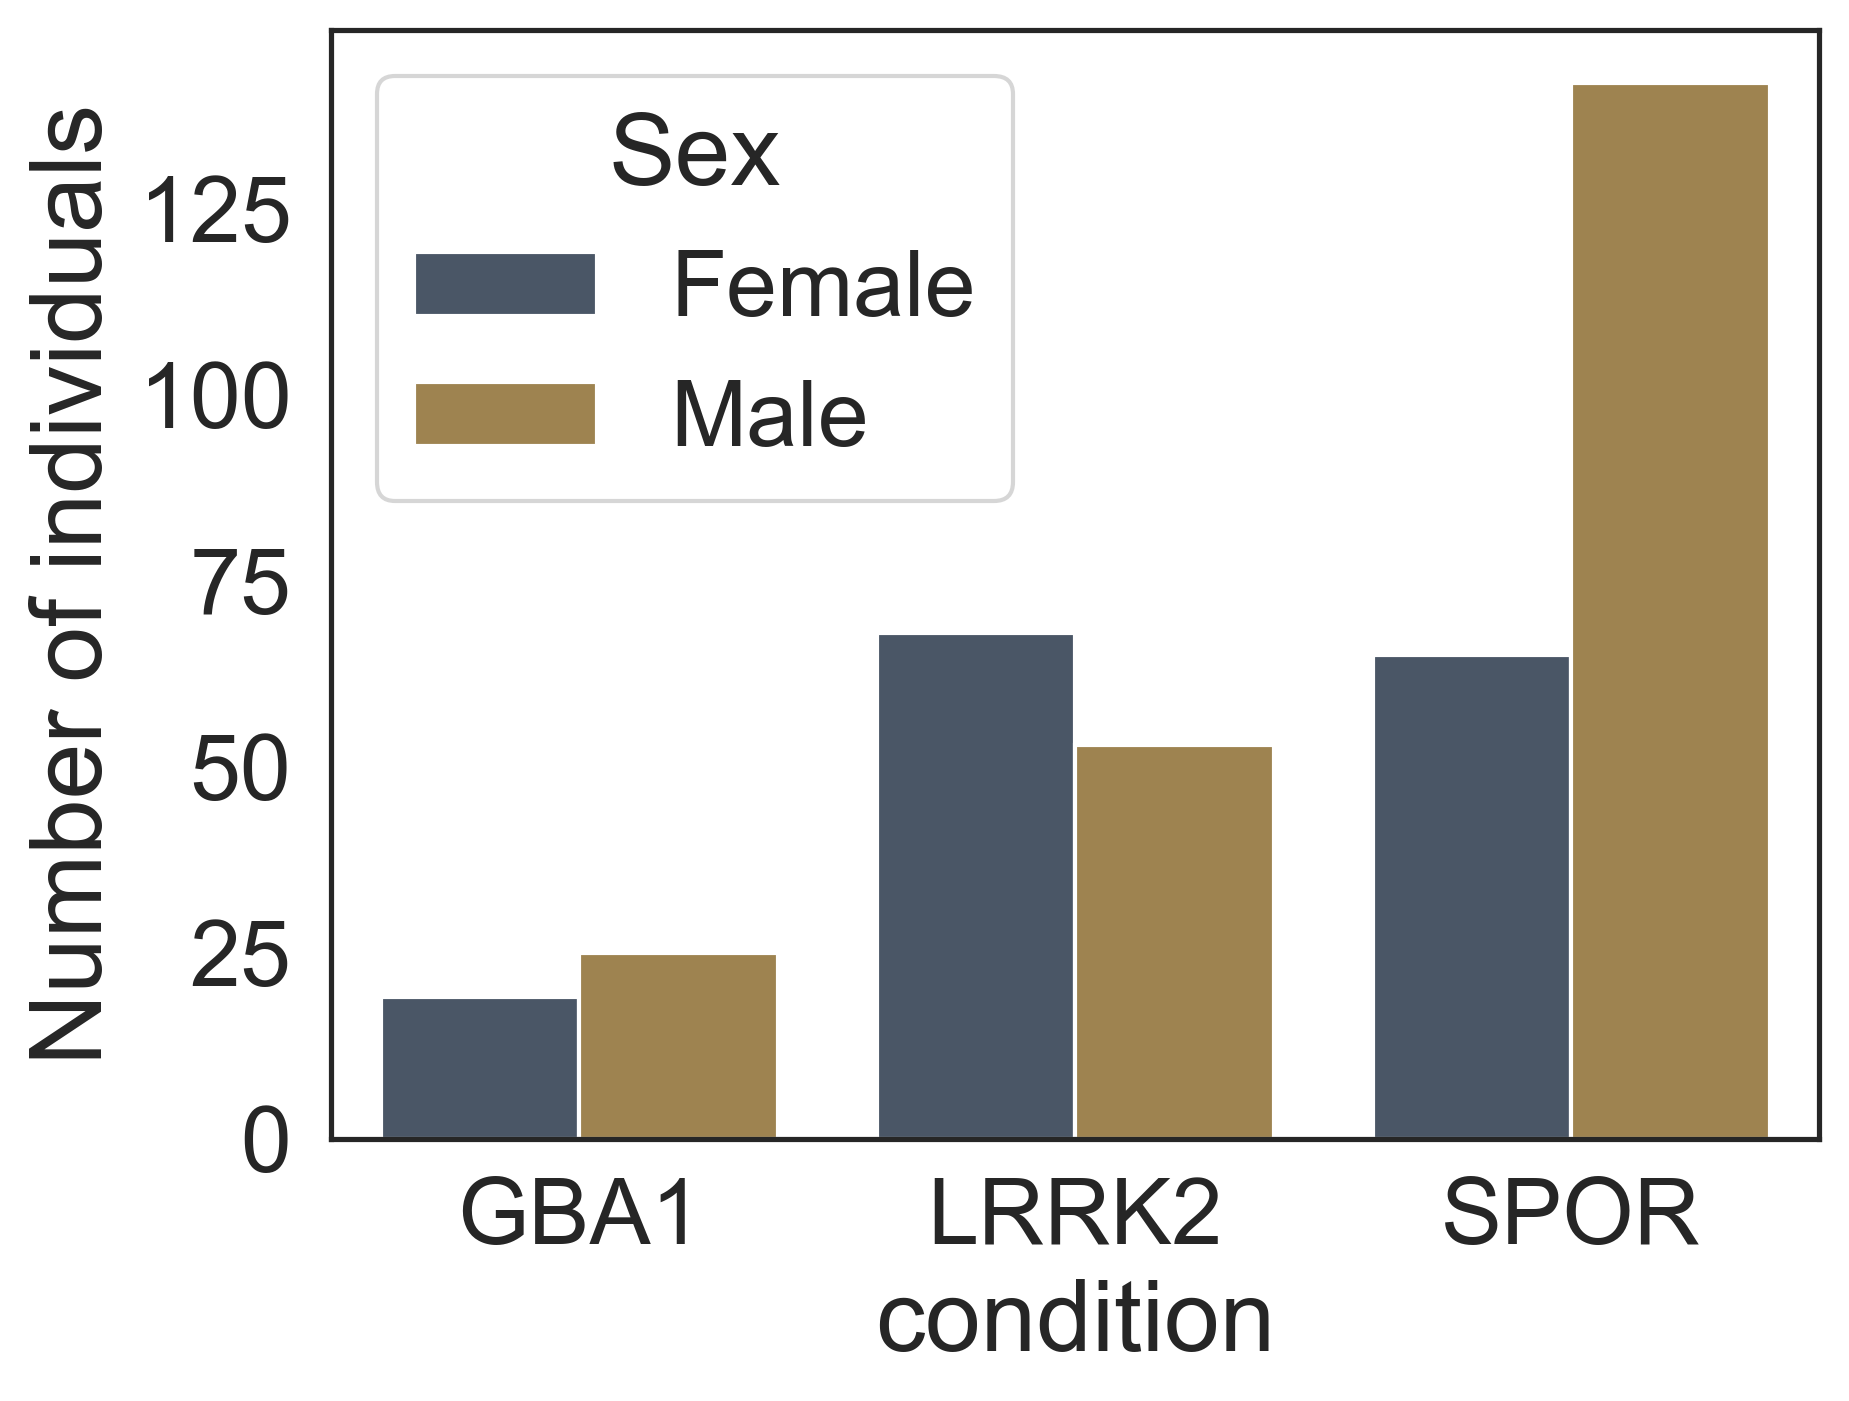

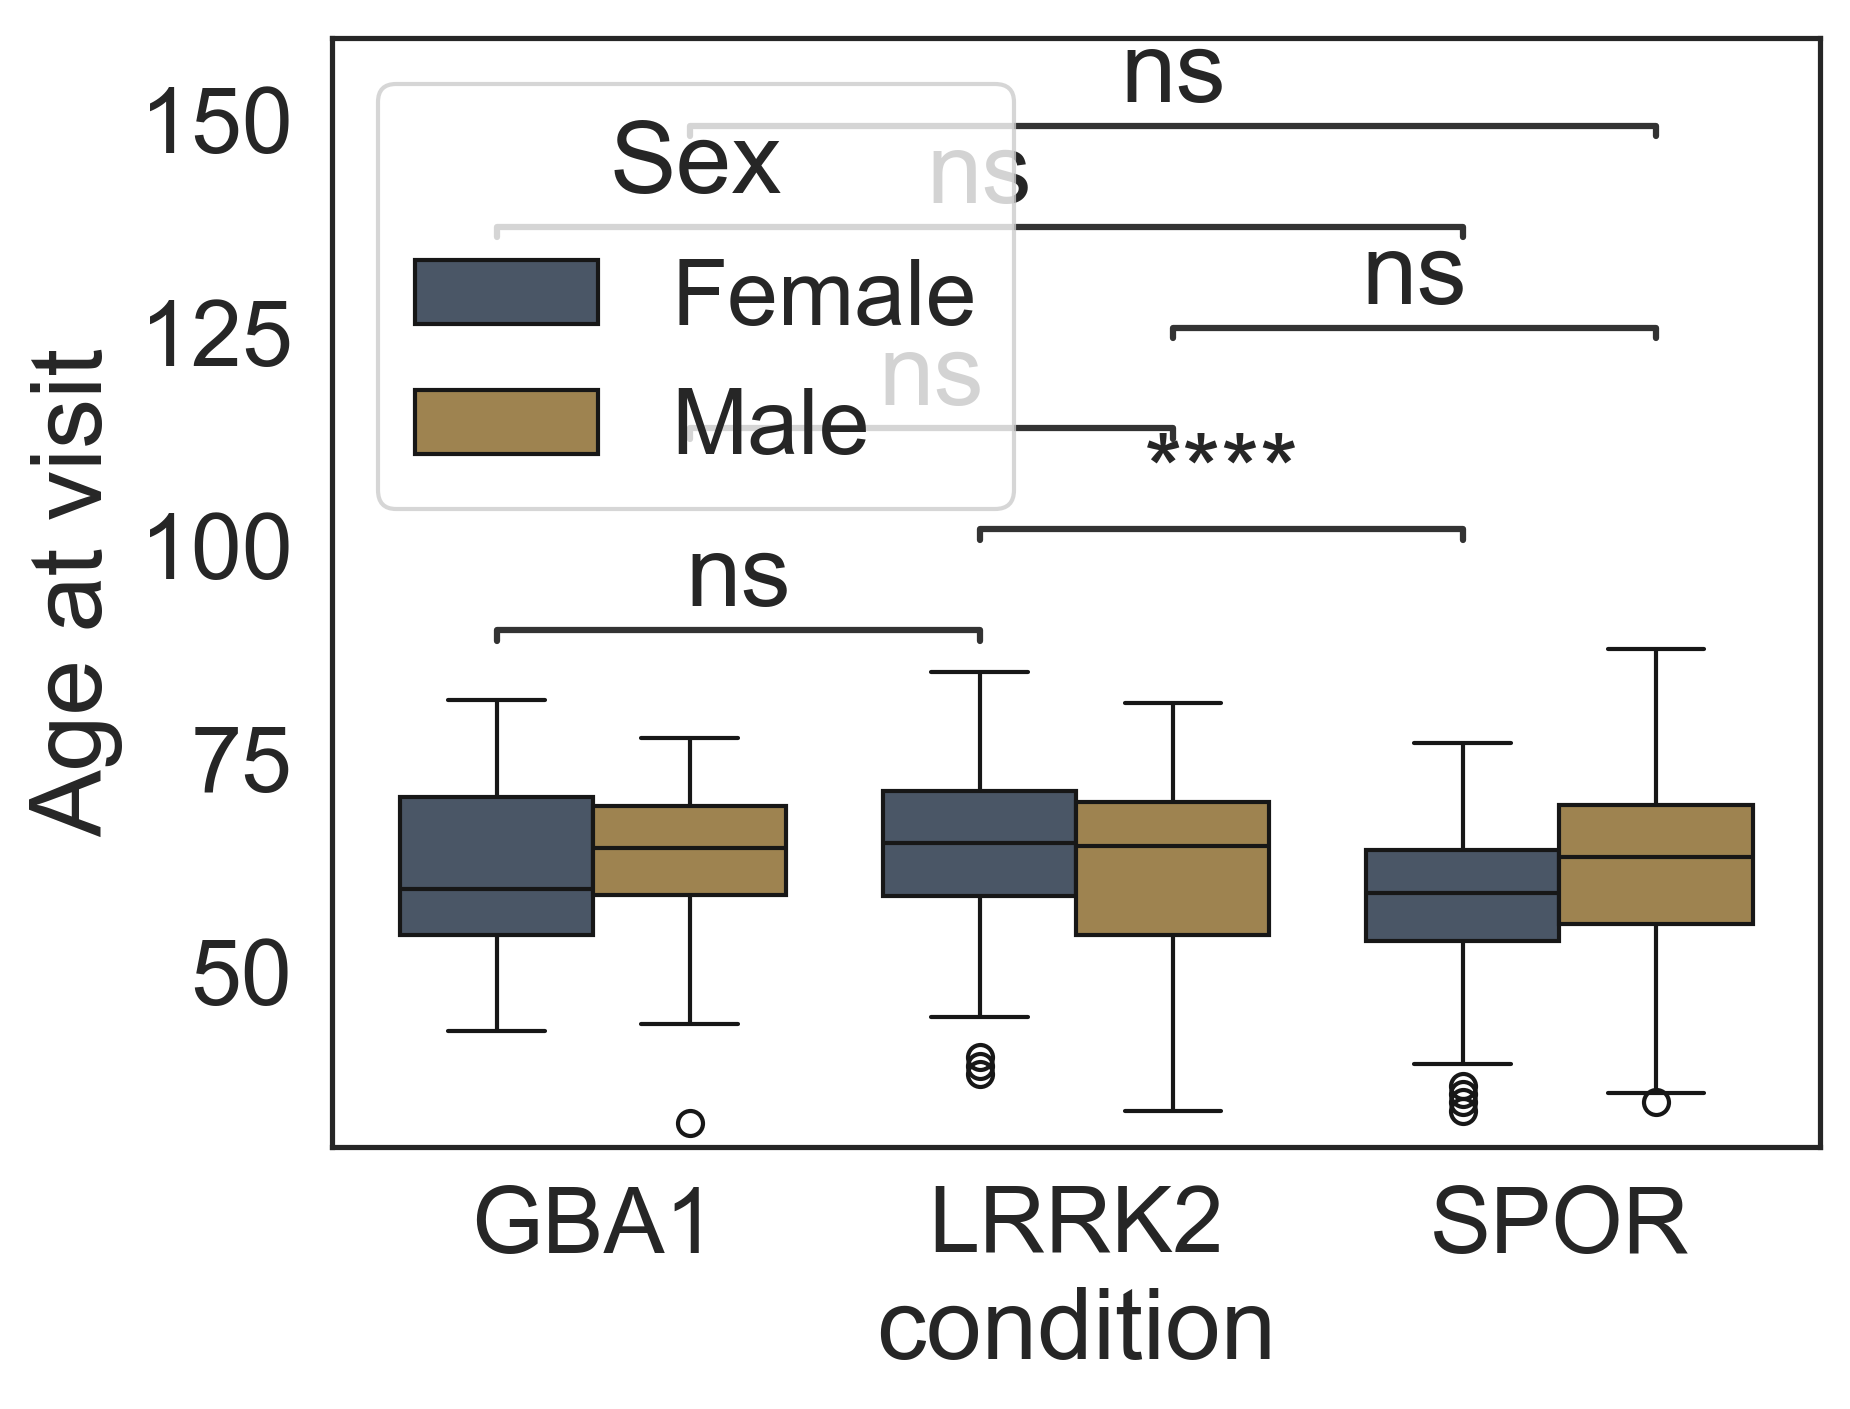

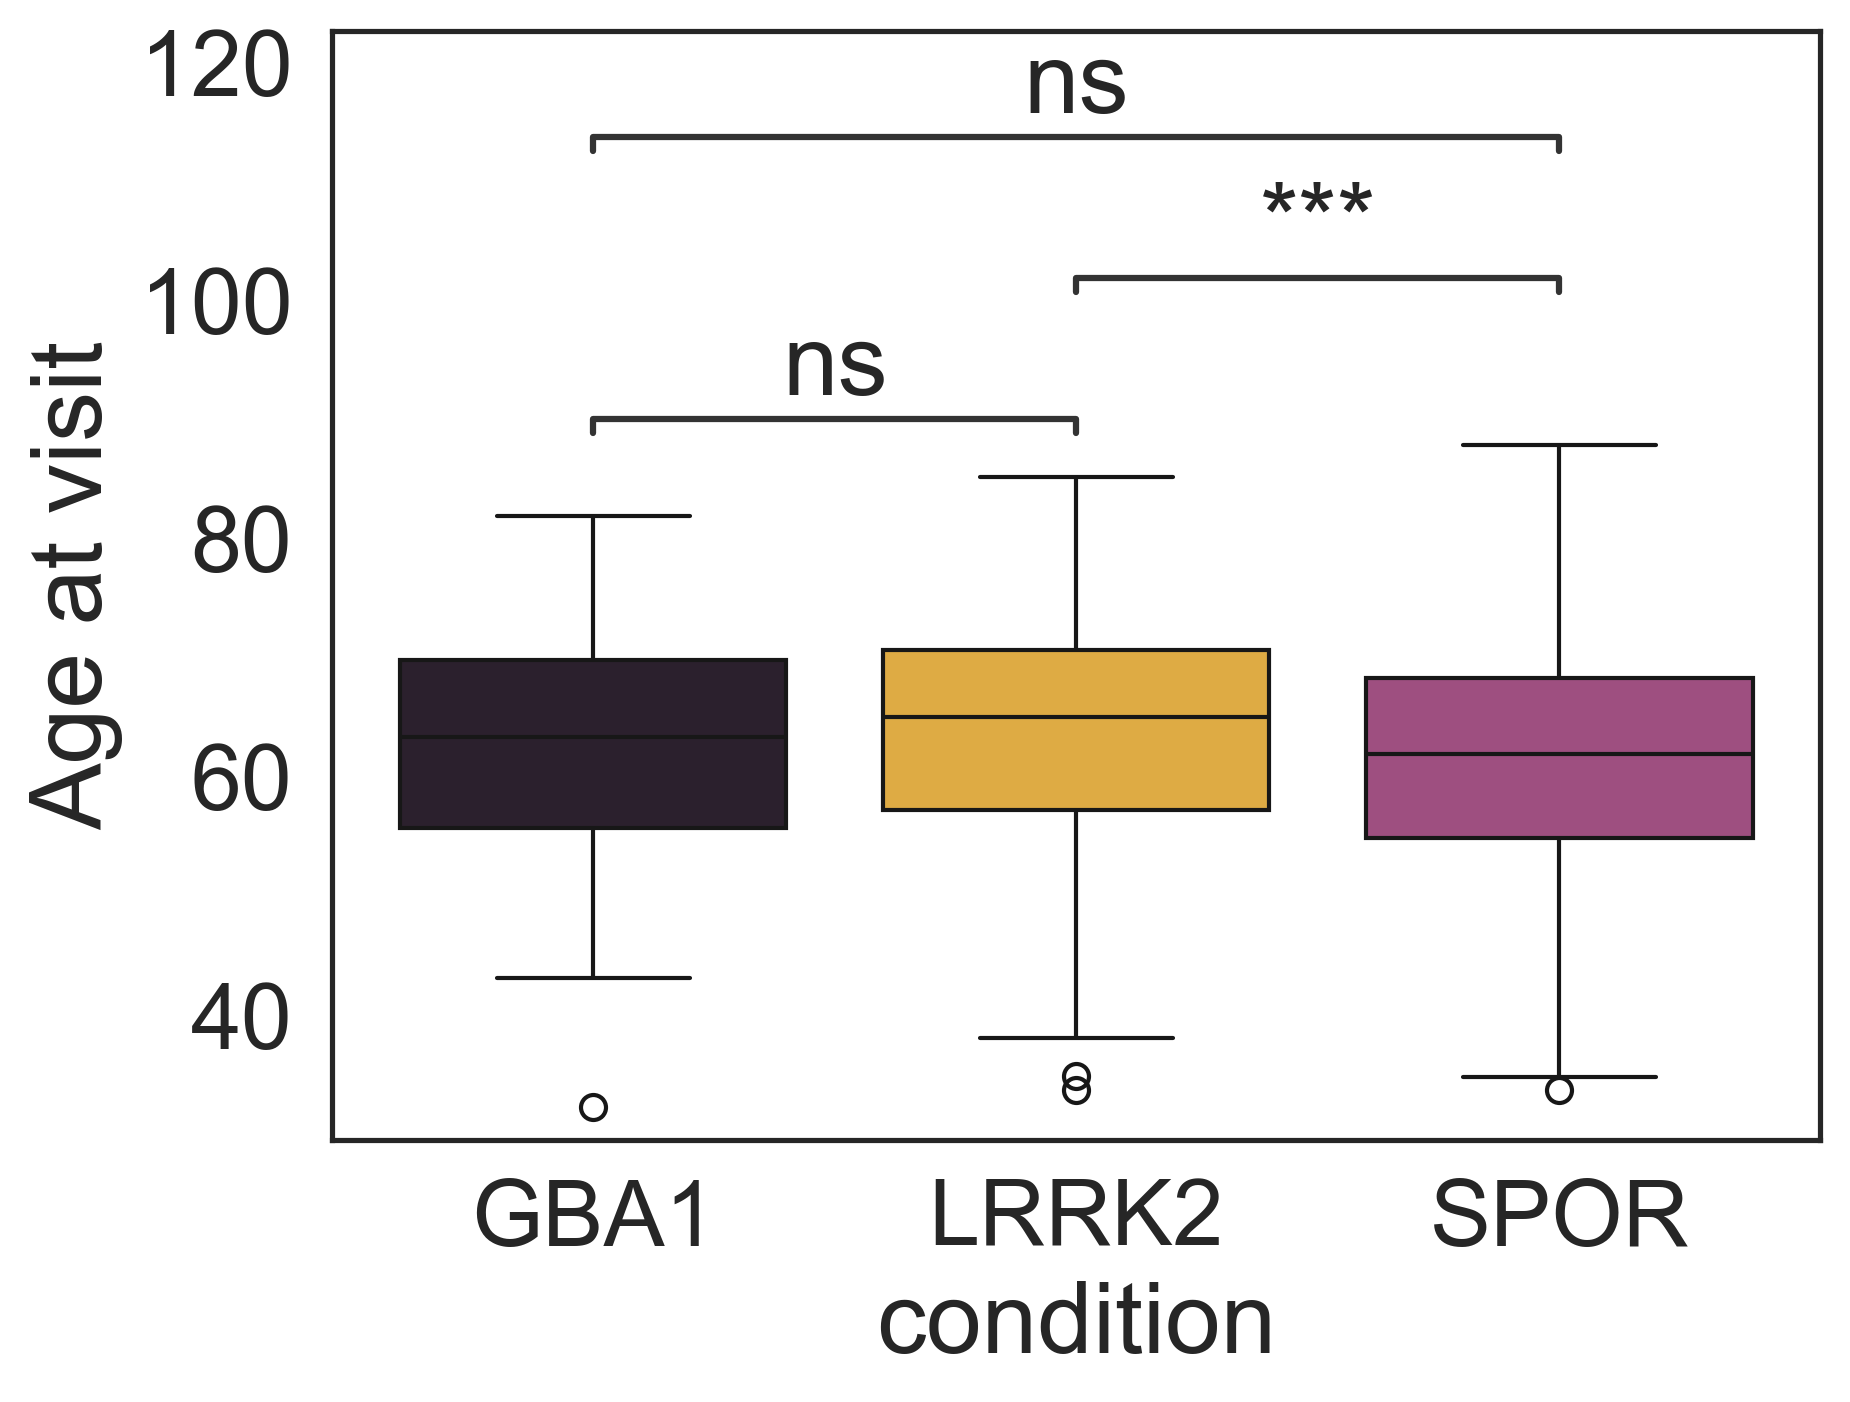

In [82]:
#KEEP all measurements for all individuals
tokeep = adata_pd.obs.sort_values("EVENT_ID").index#.drop_duplicates("PATNO", keep="first").index
adata_pd_unique = adata_pd[tokeep]
adata_pd_unique
adata_pd_bl = adata_pd_unique#[adata_pd.obs["EVENT_ID"]=="BL"]
adata_pd_bl.obs["Sex"] = adata_pd_bl.obs["SEX"].replace({0:"Female", 1:"Male"})
adata_pd_bl.obs["Age at visit"] = adata_pd_bl.obs["AGE_AT_VISIT"].tolist()
sns.set(style="white", font_scale=2)

fig, ax = plt.subplots()
toplot = adata_pd_bl.obs.groupby(["condition","Sex"]).PATNO.nunique().reset_index()
sns.barplot(data=toplot, ax=ax,x="condition", y="PATNO", hue="Sex", palette=COLORS_CT)
ax.set_ylabel("Number of individuals")
plt.savefig("./figures/barplot_blood_transcripts__sex.svg")



fig, ax = plt.subplots()
sns.boxplot(data=adata_pd_bl.obs, ax=ax,x="condition", y="Age at visit", hue="Sex", palette=COLORS_CT)
pairs=[(("GBA1", "Female"),("SPOR","Female")),(("LRRK2","Female"),("GBA1", "Female")),
           (("LRRK2","Female"),("SPOR","Female")),
      (("GBA1", "Male"),("SPOR","Male")),(("LRRK2","Male"),("GBA1", "Male")),
           (("LRRK2","Male"),("SPOR","Male"))
      ]
annotator= Annotator(pairs=pairs,ax=ax,data=adata_pd_bl.obs,x="condition", y="Age at visit", hue="Sex",
                         order=['GBA1','LRRK2','SPOR'])
                         # order=['CTRL','GBA1','LRRK2','SPOR'])
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Benjamini-Hochberg')
annotator.apply_and_annotate()
plt.savefig("./figures/barplot_blood_transcripts_age_at_visit_between_condition_strat_sex.svg")
fig, ax = plt.subplots()
sns.boxplot(data=adata_pd_bl.obs, ax=ax,x="condition", y="Age at visit", #hue="Sex", 
                    palette=COLORS_CT)
pairs=[(("GBA1", "Female"),("SPOR","Female")),(("LRRK2","Female"),("GBA1", "Female")),
           (("LRRK2","Female"),("SPOR","Female")),
      (("GBA1", "Male"),("SPOR","Male")),(("LRRK2","Male"),("GBA1", "Male")),
           (("LRRK2","Male"),("SPOR","Male"))
      ]
pairs=[("GBA1","SPOR"),("LRRK2", "GBA1"),
           ("LRRK2","SPOR")]
annotator= Annotator(pairs=pairs,ax=ax,data=adata_pd_bl.obs,x="condition", y="Age at visit", #hue="Sex",
                         order=['GBA1','LRRK2','SPOR'])
                         # order=['CTRL','GBA1','LRRK2','SPOR'])
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Benjamini-Hochberg')
annotator.apply_and_annotate()
plt.savefig("./figures/barplot_blood_transcripts_age_at_visit_between_condition.svg")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GBA1 vs. LRRK2: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.799e-01 U_stat=8.758e+03
LRRK2 vs. SPOR: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.793e-86 U_stat=1.817e+05
GBA1 vs. SPOR: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.660e-26 U_stat=4.095e+04


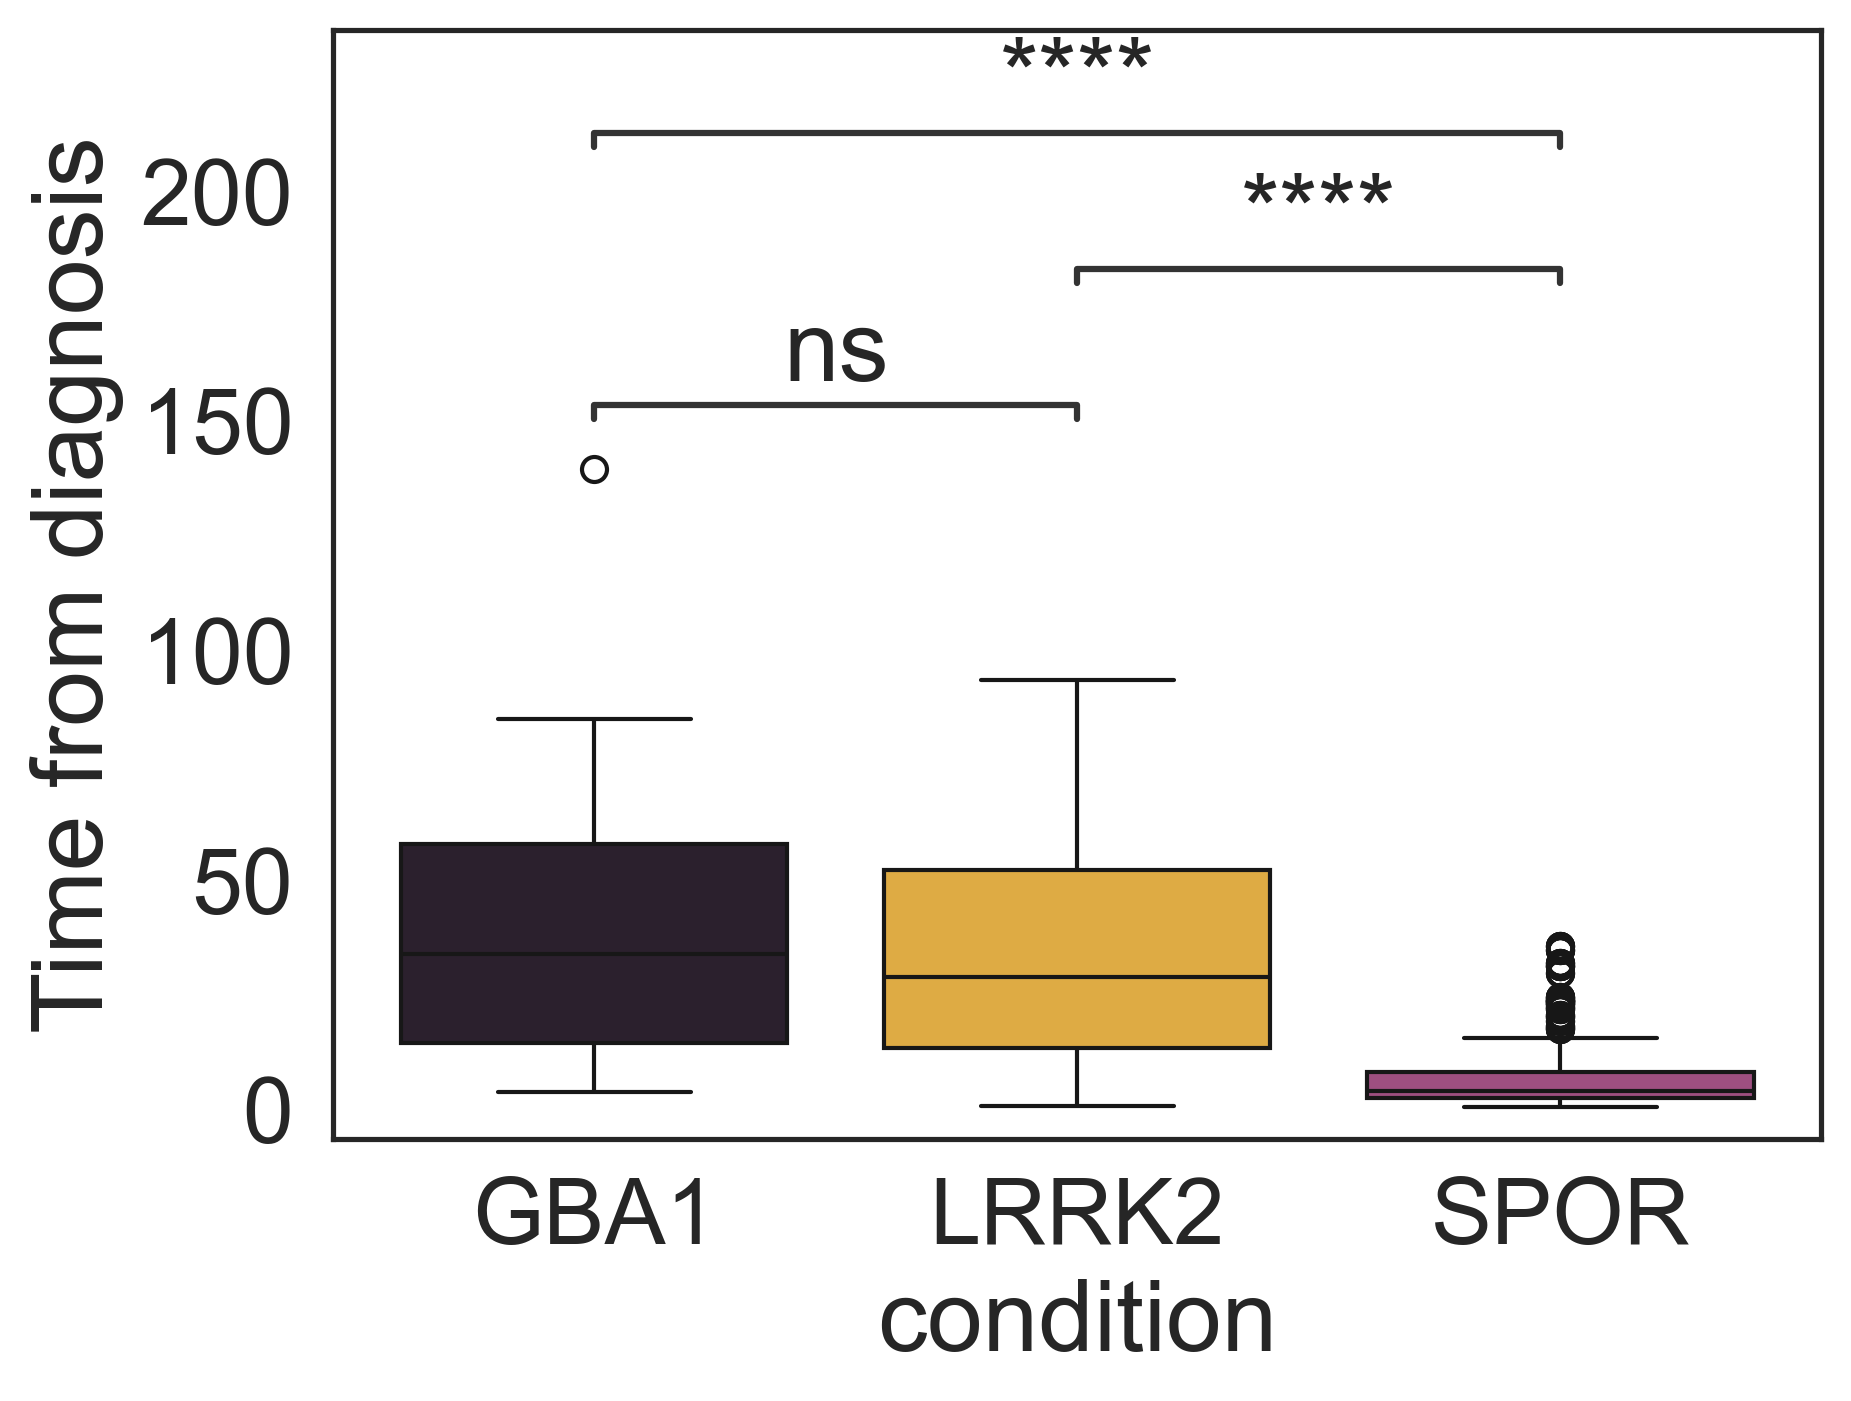

In [13]:
fig, ax = plt.subplots()
adata_pd_bl.obs["Time from diagnosis"] = adata_pd_bl.obs["duration"].tolist()
sns.boxplot(ax=ax, data=adata_pd_bl.obs, x="condition", y="Time from diagnosis", hue="condition", palette=COLORS_CT)#, hue="Sex", palette=COLORS_CT)
pairs=[(("GBA1", "GBA1"),("SPOR","SPOR")),(("LRRK2","LRRK2"),("GBA1", "GBA1")),
           (("LRRK2","LRRK2"),("SPOR","SPOR"))]
pairs=[("GBA1","SPOR"),("LRRK2", "GBA1"),
           ("LRRK2","SPOR")]

annotator= Annotator(pairs=pairs,ax=ax,data=adata_pd_bl.obs,x='condition',y="Time from diagnosis", hue="condition",
                         order=['GBA1','LRRK2','SPOR'])
                         # order=['CTRL','GBA1','LRRK2','SPOR'])
annotator.configure(test='Mann-Whitney', text_format='star',comparisons_correction='Benjamini-Hochberg')
annotator.apply_and_annotate()
plt.savefig("./figures/barplot_blood_transcripts_duration_between_condition.svg")

In [ ]:
peaks_df = differential_expression(adata_pd_bl, 0, method, corr_=["SEX"], columns="group_separate", refit=True)
peaks_df
peaks_df.to_pickle("./res_DE_blood_transcripts_bulk_all_separate_sex_adjusted.pickle")

['RNU1-1-201' 'COL6A3-212' 'SNORA26-201' 'SNORA38-201' 'SNORA65-201'
 'RNU6ATAC-201' 'SNORD67-201' 'RNU2-2P-201' 'RPS25-206' 'GAPDH-211'
 'RNU4-2-201' 'RNU5A-1-201' 'RPL13-207' 'SREBF1-210' 'SNORA37-201']


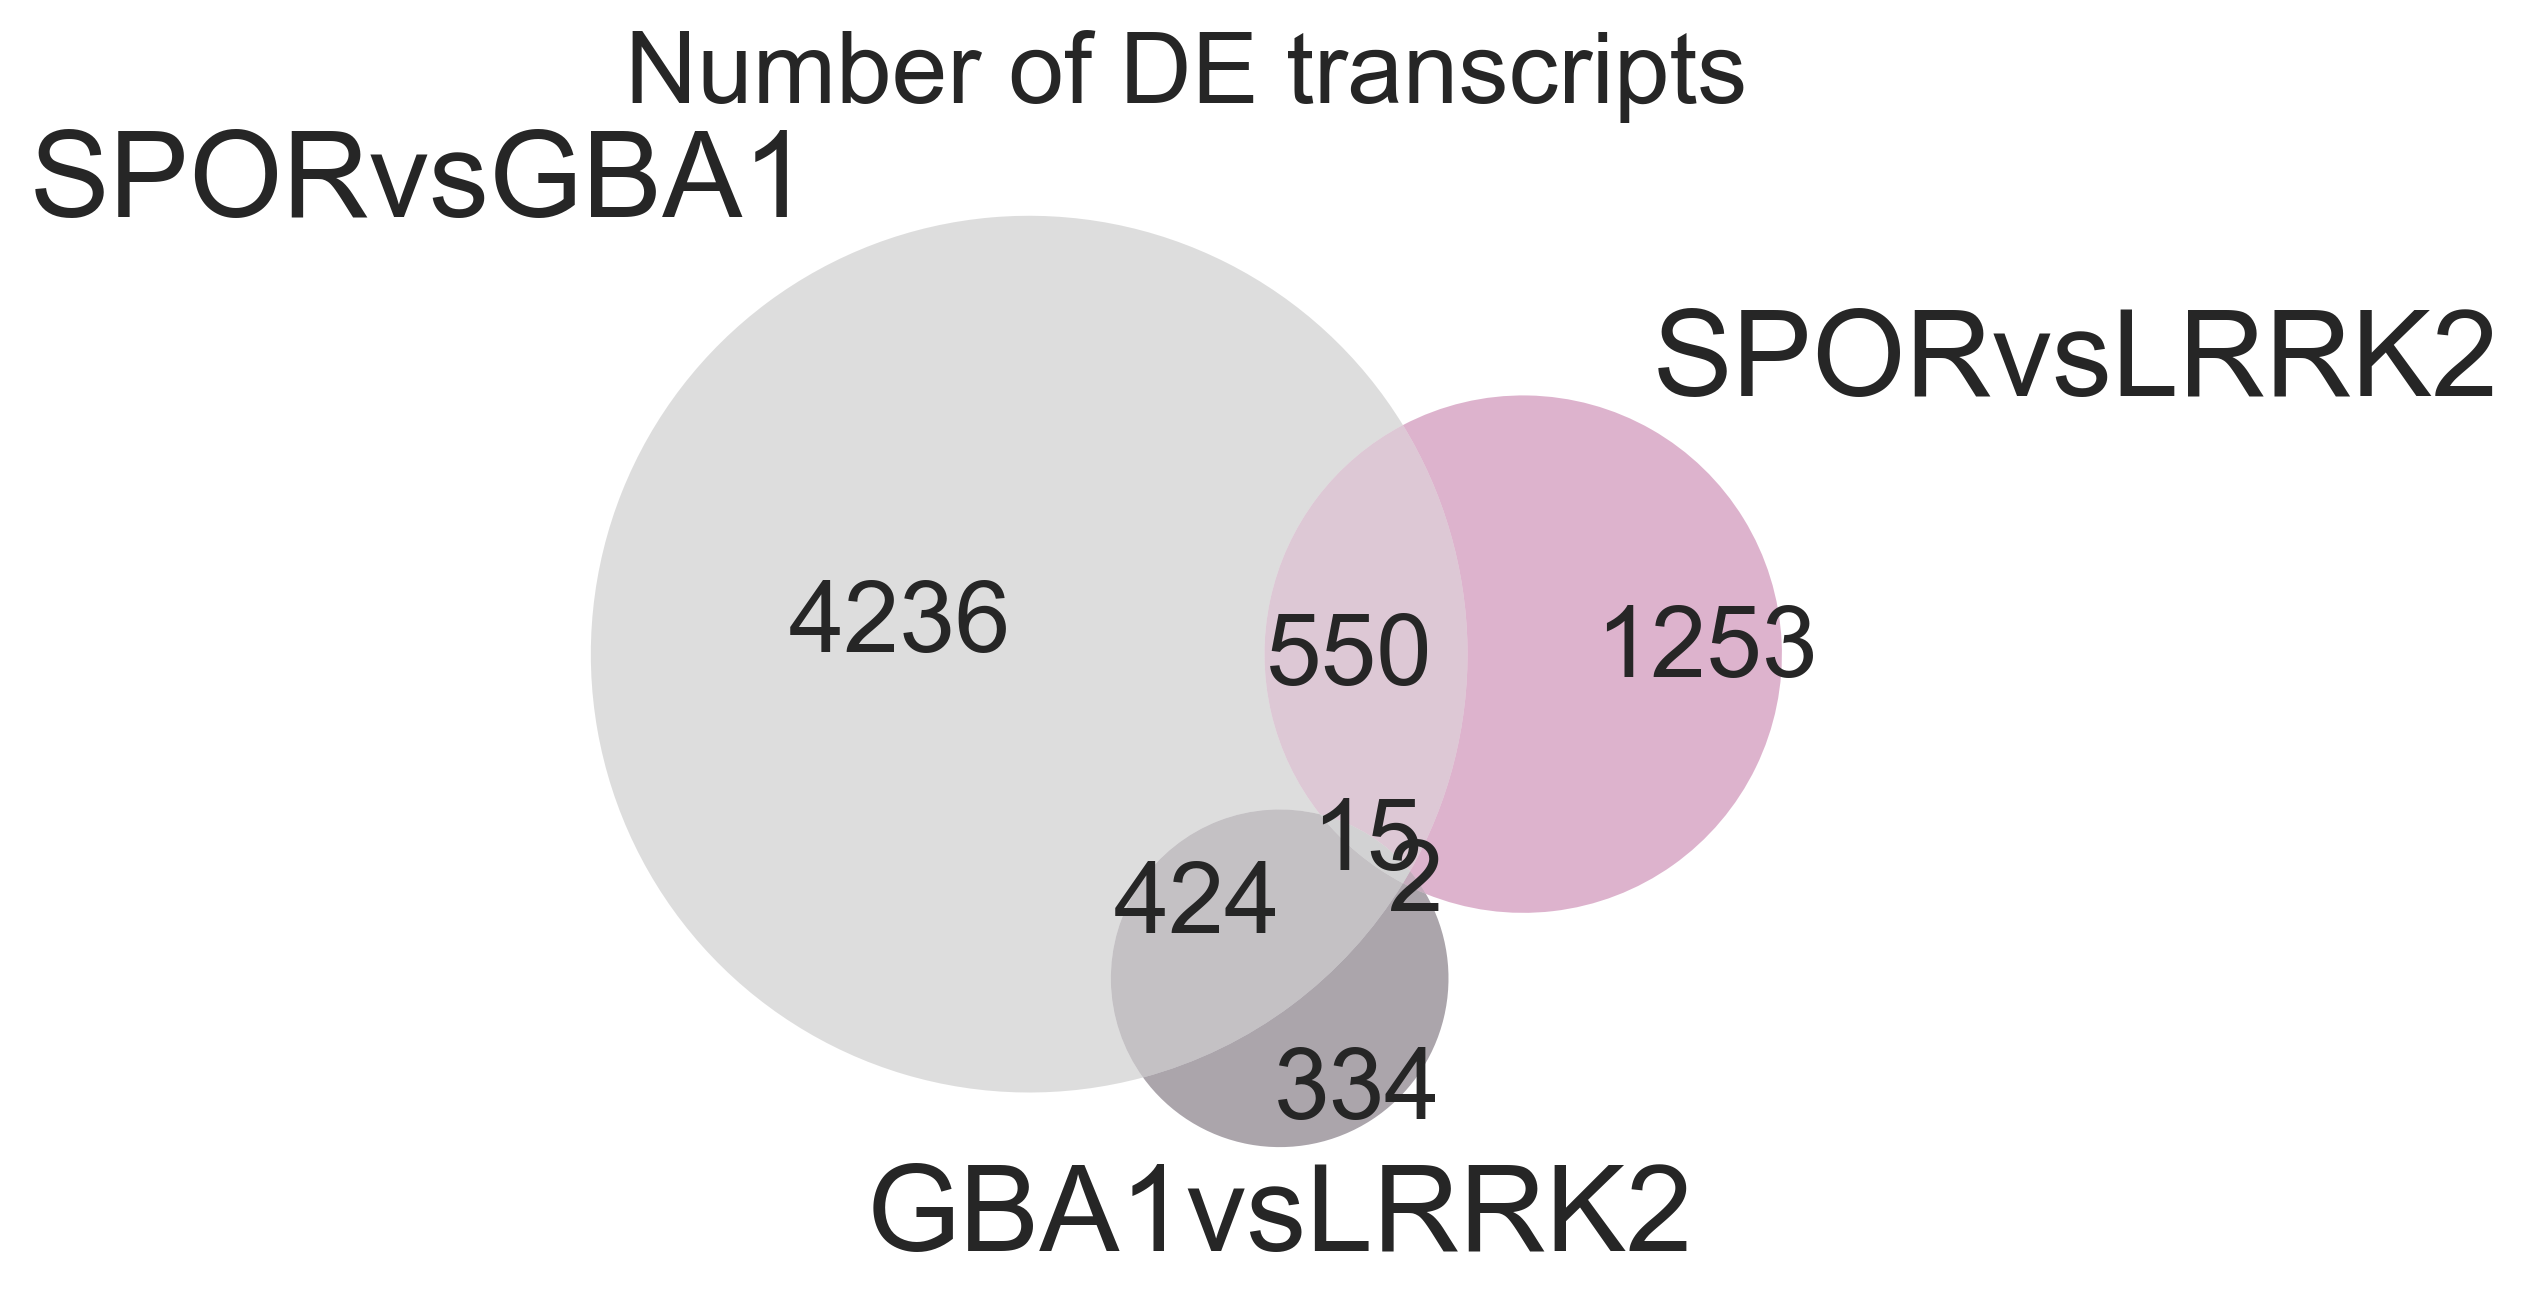

In [83]:
peaks_df = pd.read_pickle("./res_DE_blood_transcripts_bulk_all_separate_sex_adjusted.pickle")
def combine_hex_values(d):
  d_items = sorted(d.items())
  tot_weight = sum(d.values())
  red = int(sum([int(k[:2], 16)*v for k, v in d_items])/tot_weight)
  green = int(sum([int(k[2:4], 16)*v for k, v in d_items])/tot_weight)
  blue = int(sum([int(k[4:6], 16)*v for k, v in d_items])/tot_weight)
  zpad = lambda x: x if len(x)==2 else '0' + x
  return zpad(hex(red)[2:]) + zpad(hex(green)[2:]) + zpad(hex(blue)[2:])

dico_pk = {it:p for it,p in zip(peaks_df.peakid,peaks_df.gene_name)}
br="SUNI"
# ct="AST"
verse = "LRRK2"
# verse = "All"
res_DE= peaks_df
tmp = res_DE[(res_DE.padj <=0.05)&(np.abs(res_DE.log2FoldChange)>0.5)]
comp1 = tmp[tmp.comparison=="SPOR$GBA1"]
comp2= tmp[tmp.comparison=="SPOR$%s"%verse]
comp3 = tmp[tmp.comparison=="GBA1$%s"%verse]
palette={"GBA1vs%s"%verse:"#2D1E2F",  "SPORvs%s"%verse:"#AB4283","SPORvsGBA1":"#ababab"}


set1 = set(comp1.peakid.tolist())
set2=set(comp2.peakid.tolist())
set3=set(comp3.peakid.tolist())
v = venn3(subsets=[set1,set2,set3],
                 set_labels = ("SPORvsGBA1","SPORvs%s"%verse, "GBA1vs%s"%verse))
v.get_patch_by_id('100').set_color(palette["SPORvsGBA1"])
v.get_patch_by_id('100').set_edgecolor('none')
v.get_patch_by_id('010').set_color(palette["SPORvs%s"%verse])
v.get_patch_by_id('010').set_edgecolor('none')
v.get_patch_by_id('001').set_color(palette["GBA1vs%s"%verse])
v.get_patch_by_id('001').set_edgecolor('none')

v110 = combine_hex_values({"ababab": 0.5, "AB4283": 0.5})
# print(v110)
v.get_patch_by_id('110').set_color("#%s"%v110)
v.get_patch_by_id('110').set_edgecolor('none')

v101 = combine_hex_values({"ababab": 0.5, "2D1E2F": 0.5})
v.get_patch_by_id('101').set_color("#%s"%v101)
v.get_patch_by_id('101').set_edgecolor('none')

v011 = combine_hex_values({"AB4283": 0.5, "2D1E2F": 0.5})
v.get_patch_by_id('011').set_color("#%s"%v011)
v.get_patch_by_id('011').set_edgecolor('none')
plt.title("Number of DE transcripts")

# v.get_label_by_id('110').set_text('\n'.join(set1 & set2 -set3))
# v.get_label_by_id('011').set_text('\n'.join(set2 & set3 -set1))
# v.get_label_by_id('101').set_text('\n'.join(set3 & set1 -set2))

peakss = list(set1 & set2 & set3)
peakss = [dico_pk[it] for it in peakss]
# v.get_label_by_id('111').set_text('\n'.join(peakss))


inter = [it for it in list(set1) if it in list(set2) if it in list(set3)]
# print(len(inter))
inter2 = [it for it in list(set1) if it in list(set2)]
inter3 = [it for it in list(set1) if it in list(set3)]
inter4 = [it for it in list(set2) if it in list(set3) if it in list(set1)]
# print(inter)#+inter2+inter3+inter4)
print(tmp[tmp.peakid.isin(inter)]["transcript_name"].unique())

plt.savefig("./outdir/Venn_blood_transcipts_OCR_bulk__%s"%(br)+ ".svg", bbox_inches="tight")
plt.show()

In [85]:
tmp = res_DE[(res_DE.padj <=0.05)&(np.abs(res_DE.log2FoldChange)>0.5)&(res_DE.comparison=="SPOR$GBA1")]
tmp
tot=5225
(550+15+424)/5225

0.1892822966507177

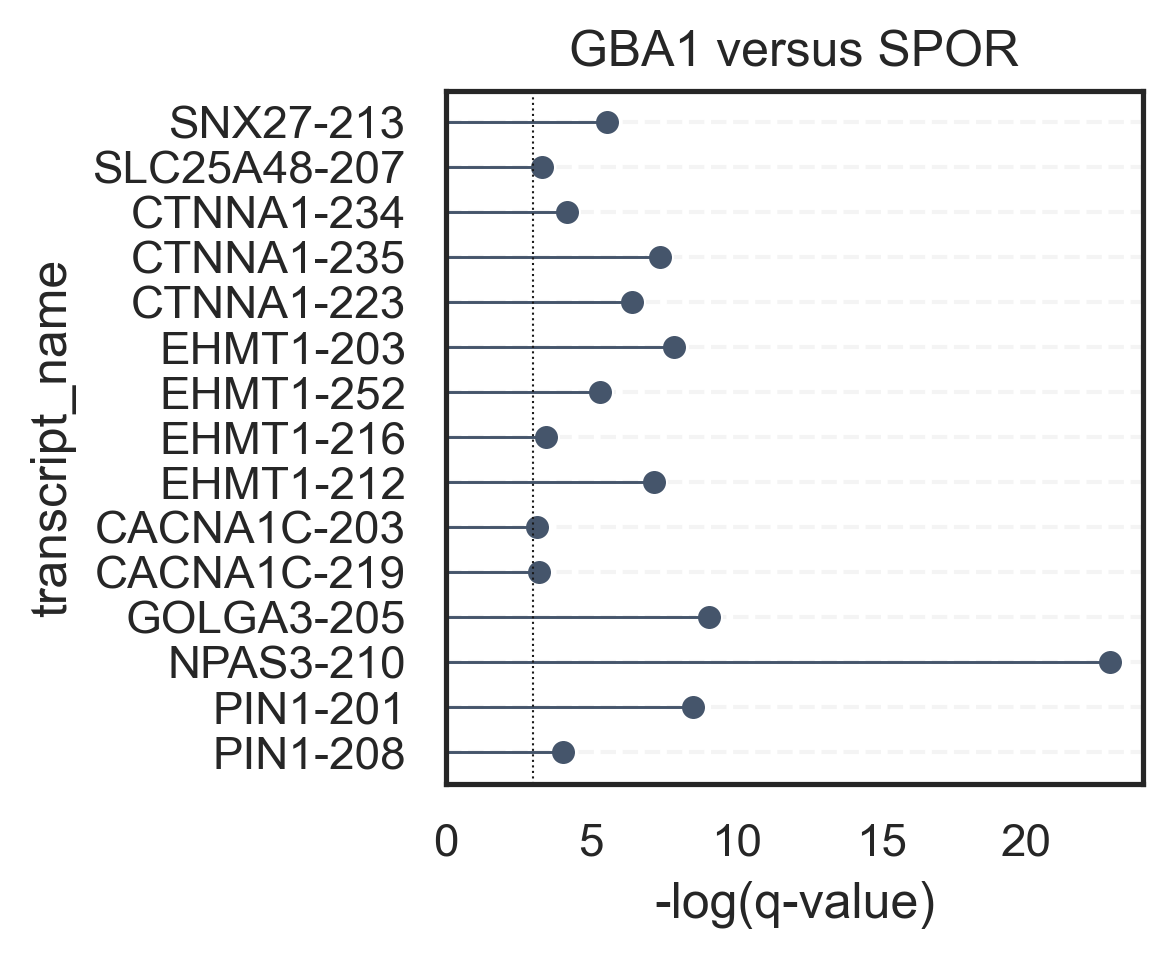

In [87]:
ll = ['FAM230C',
 'NMUR2',
 'SHANK2-AS1',
 'SULT4A1',
 'CACNA1B',
 'SNX27',
 'PIN1',
 'CACNA1C',
 'SLC25A48',
 'CTNNA1',
 'L3MBTL4-AS1',
 'CPM',
 'MYZAP',
 'ATP2B3',
 'EHMT1',
 'GOLGA3',
 'NPAS3']


tmpp = peaks_df[((peaks_df.gene_name.isin(ll)) 
                 & (peaks_df.padj<=0.05) 
                 &(peaks_df.comparison == "SPOR$GBA1"))][
        ["comparison", "padj","log2FoldChange", "transcript_name"]]#.unique().tolist()

y = "transcript_name"
tmpp["-log(q-value)"] = -np.log(tmpp["padj"])
fig, ax = plt.subplots(figsize=(3,3))
sns.set(font_scale=1, style="white")
sns.scatterplot(data=tmpp,ax=ax, x="-log(q-value)", y=y, color="#45556B")
list_=tmpp[y].tolist()
for i, category in enumerate(list_):
    ax.plot([0, tmpp.iloc[i]["-log(q-value)"]], [i, i], color="#45556B", lw=0.7, zorder=2)

ax.grid(axis='y', linestyle='--', alpha=0.2)
ax.set_xlim(0)
ax.axvline(x=-np.log(0.05), c="k", linestyle=":", linewidth=0.5)
ax.set_title("GBA1 versus SPOR")
plt.savefig("./outdir/Validation_SPOR_GBA1_transcripts.svg", bbox_inches="tight")

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_90357/2782315650.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  toplot["size"] = 3


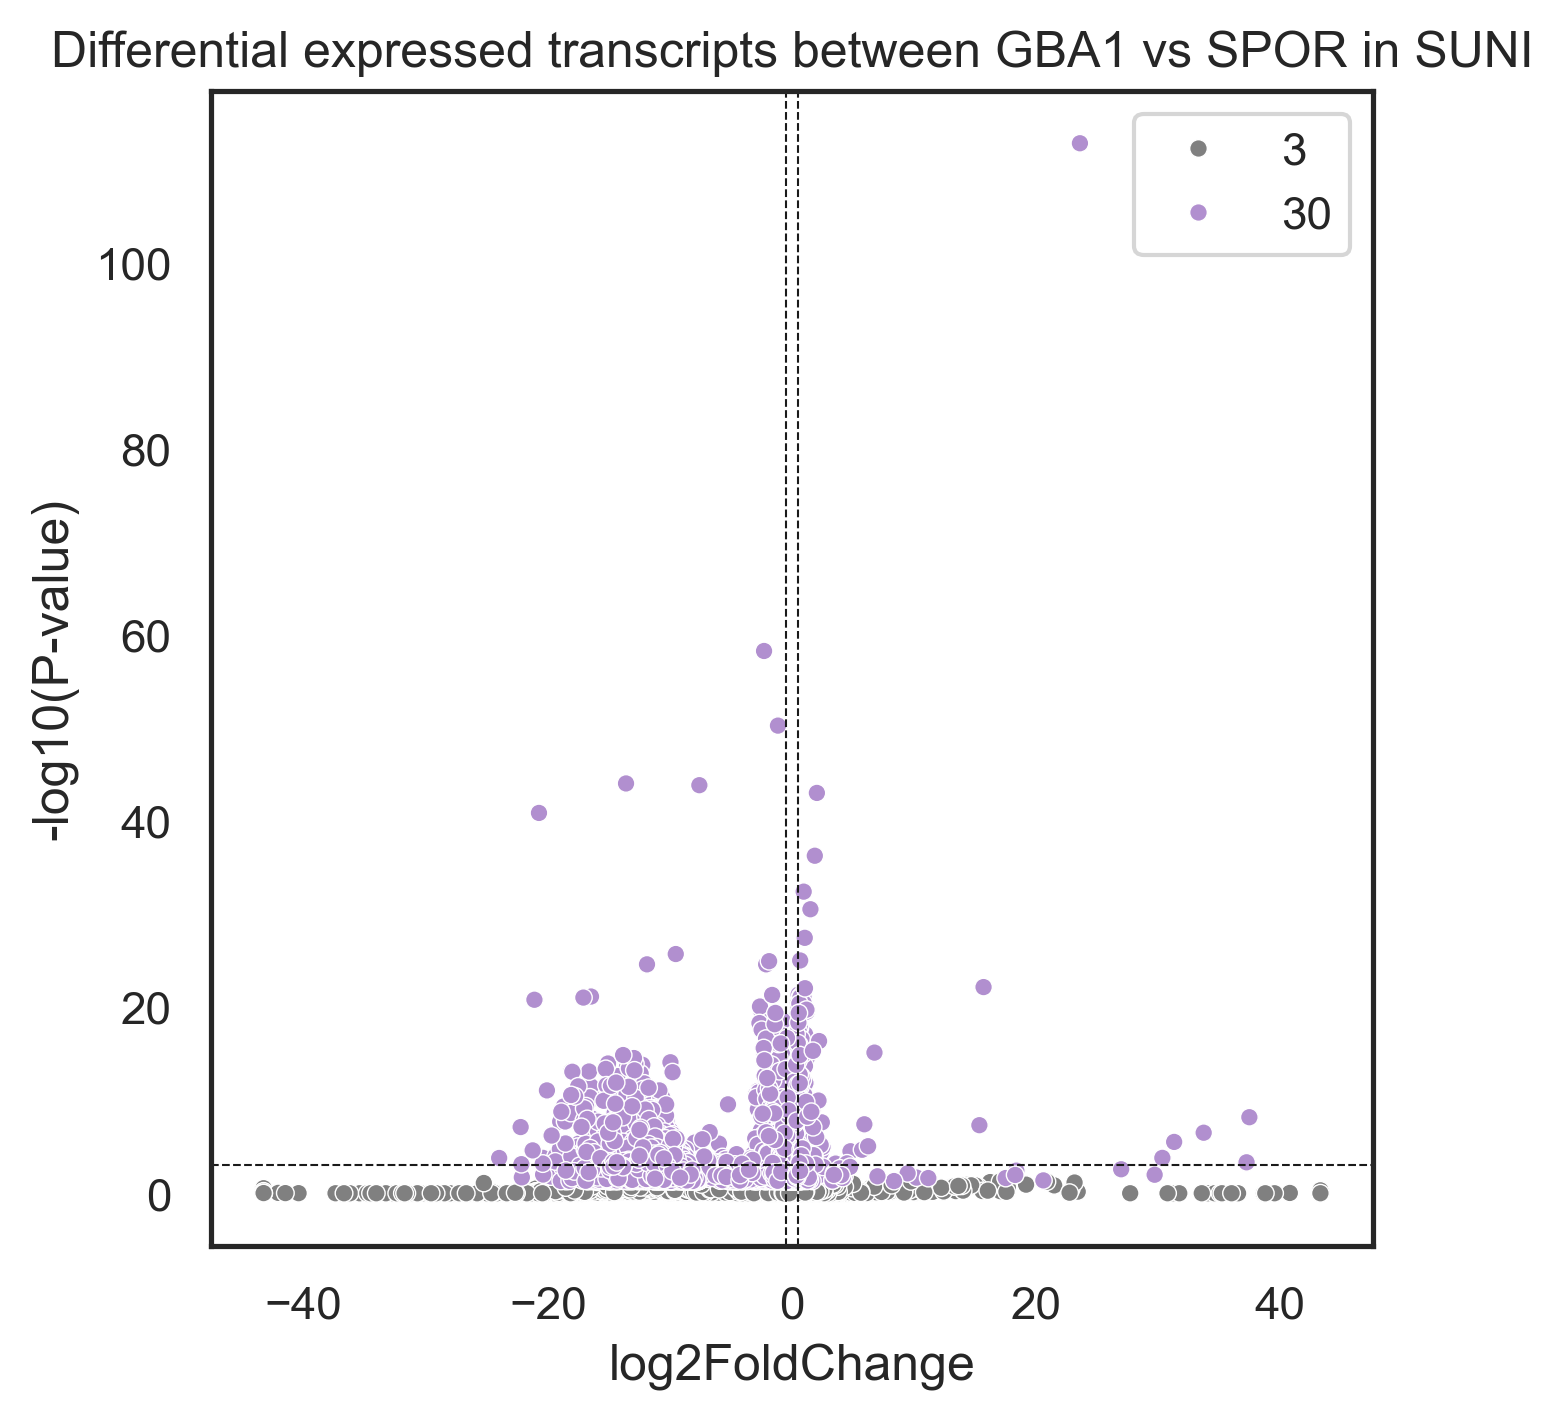

In [88]:
pal = {"3' UTR":"#b18fcf","Promoter":"#42253b", "Intron":"#ffa552","Exon":"#82c0cc","Distal Intergenic":"#82d173"}

peaks_df["-log10(P-value)"] = -np.log10(peaks_df["padj"])
toplot = peaks_df[(peaks_df.comparison=="SPOR$GBA1")]

fig, ax = plt.subplots(figsize=(5,5))
x="log2FoldChange"
y="-log10(P-value)"
toplot["size"] = 3
sns.scatterplot(data = toplot[toplot.padj>0.05], x=x, y=y, color="gray", size=3,)
sns.scatterplot(data = toplot[toplot.padj<=0.05], x=x, y=y, color="#b18fcf", size=30,
               )#palette=pal)
ax.axhline(y=-np.log(0.05), c="k", linestyle="--", linewidth=0.5)
ax.axvline(x=-0.5, c="k", linestyle="--", linewidth=0.5)
ax.axvline(x=0.5, c="k", linestyle="--", linewidth=0.5)
ax.legend(bbox_to_anchor=(1,1))

# texts = []
# for i, it in enumerate(toplot[toplot.padj<=0.05].iterrows()):
#     text = plt.text(it[1][x], it[1][y], it[1]["transcript_name"], fontsize=10)#, color=pal[it[1]["annot"]])
#     texts.append(text)

# # Adjust text to avoid overlap
# adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black'))
# ax.set_xlim(-20, 20)
ax.set_title("Differential expressed transcripts between GBA1 vs SPOR in SUNI")
plt.savefig("outdir/volcano_bulk_DE_blood.svg")
plt.show()

In [90]:
gtf = "/Users/eloiseberson/Downloads/gencode.v29.annotation.gtf.gz"
gf = read_gtf(gtf).to_pandas()


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'havana_gene', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'tag', 'havana_transcript', 'exon_number', 'exon_id', 'ont', 'protein_id', 'ccdsid']


In [91]:
valid_gene = gf[gf.feature=="gene"]["gene_name"].unique()
len(valid_gene)

57133

In [92]:
inter2 = [it for it in list(set1) if it in list(set2)]
inter2 += [it for it in list(set1) if it in list(set3)]


res_DE = peaks_df[(peaks_df.comparison=="SPOR$GBA1")]
gene_list = res_DE[(res_DE.padj<=0.05) &(np.abs(res_DE.log2FoldChange)>5)]["gene_name"].str.split(".",expand=True)[0].astype(str).unique().tolist()
# gene_list = adata_pd_bl.var[adata_pd_bl.var.peakid.isin(inter2)]["gene_name"].str.split(".",expand=True)[0].astype(str).unique().tolist()
gene_list = [it for it in gene_list if it in valid_gene]

bg = adata_pd_bl.var.gene_name.str.split(".",expand=True)[0].astype(str).unique().tolist()
bg = [it for it in bg if it in valid_gene]
enr = gp.enrich(gene_list, # or "./tests/data/gene_list.txt",
                 background=bg,
                 # permutation=10000,
                 # pheno_pos = "SPOR",
        # pheno_neg = "GBA1",
                 gene_sets=['KEGG_2021_Human'],#
                 # gene_sets=['GO_Biological_Process_2023','GO_Cellular_Component_2023','GO_Molecular_Function_2023'],
                 # organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                )

len(gene_list)

3010

In [105]:
enr.res2d.sort_values("Combined Score", ascending=False).to_csv("blood_pathway_enrichment.csv")

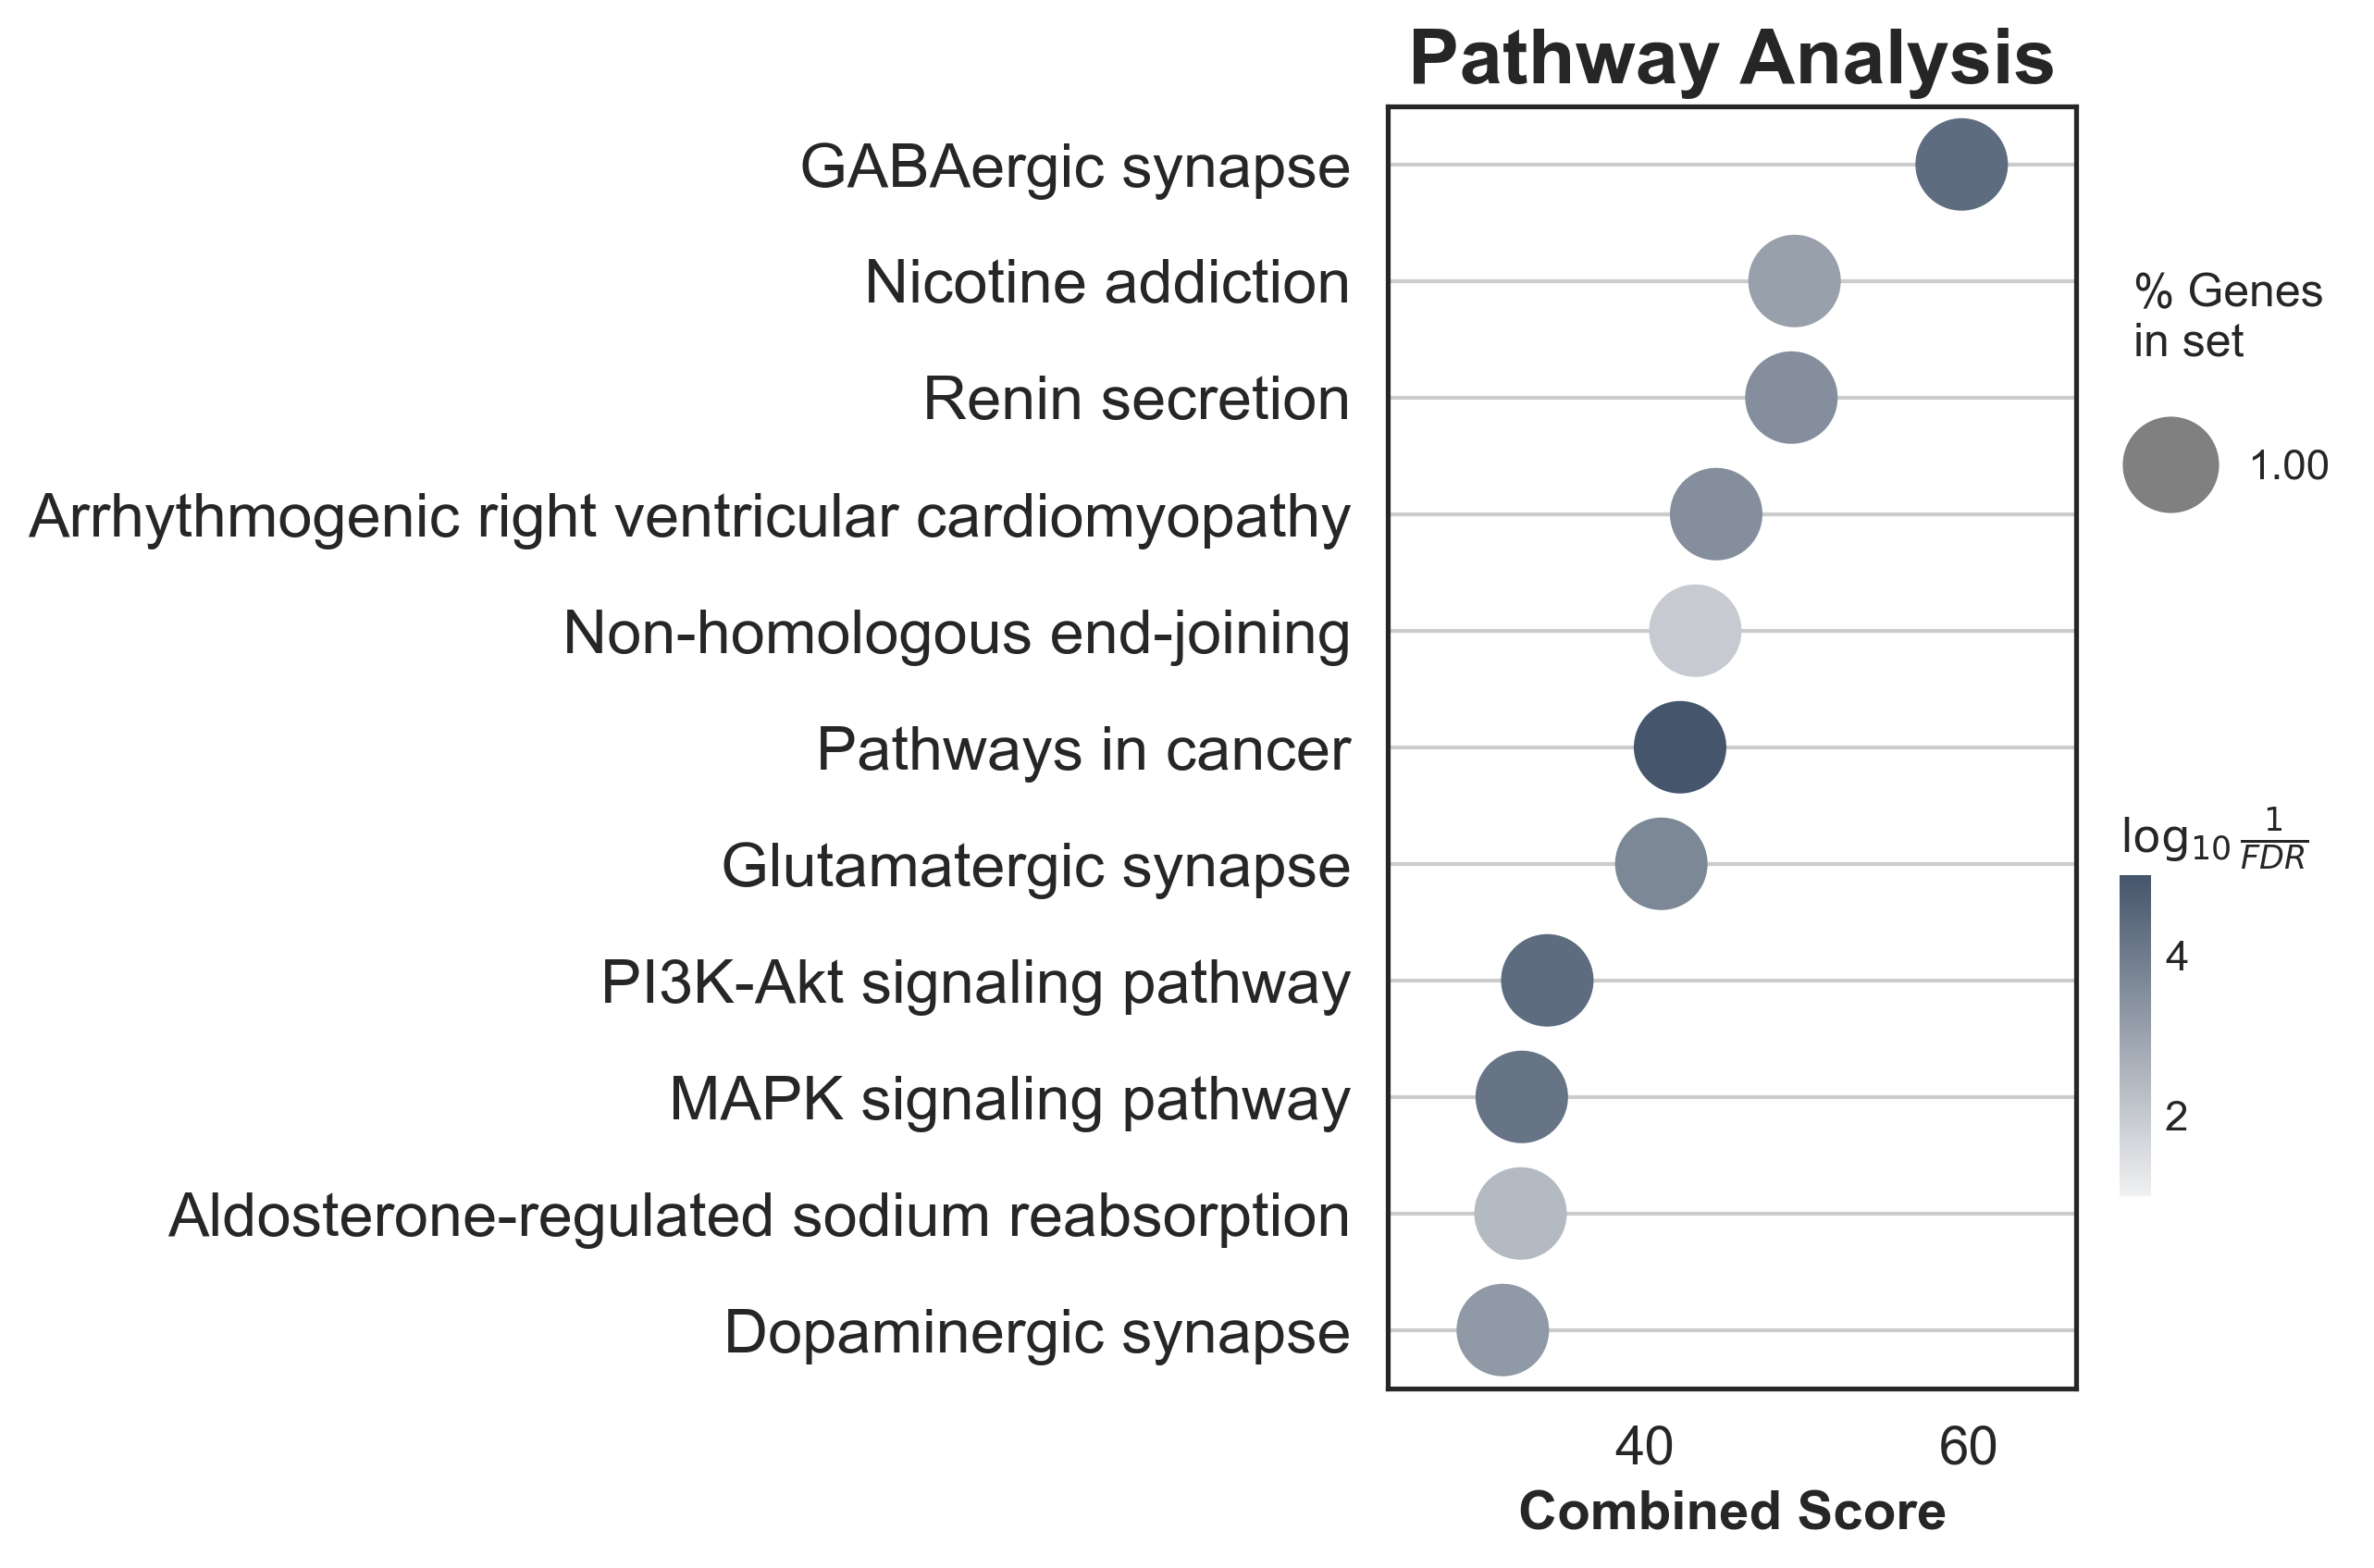

In [104]:
term = enr.res2d.copy()
term = enr.res2d.sort_values("Combined Score", ascending=False)[:11]
term["Number of genes"] = term["Genes"].apply(lambda x : len(x.split(";")))
term["-log(qvalue)"] = -np.log(term['Adjusted P-value'])
term.Term = term.Term.str.replace("KEGG_2021_Human__","")
ax = gp.dotplot(term,
             # column="-log(qvalue)",
                # column="Number of genes",
                # raw="-log(qvalue)",
             title='Pathway Analysis',
             cmap=cmap,
              top_term=11,
             size=4, # adjust dot size
             figsize=(4,6), cutoff=1, show_ring=False)
plt.savefig("outdir/pathway_blood_de.svg")
plt.show()

In [109]:
enr.res2d.sort_values("Combined Score", ascending=False)[:11]

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
2,KEGG_2021_Human,GABAergic synapse,3.680453e-07,0.000038,0,0,4.020351,59.561738,GABRB3;GABRA2;GABRA1;GABRP;GABARAPL1;SLC12A5;P...
16,KEGG_2021_Human,Nicotine addiction,4.598626e-05,0.000847,0,0,4.931573,49.252452,GABRB3;GABRA2;GRIA2;GABRA1;GABRP;CHRNA4;GABRA5...
5,KEGG_2021_Human,Renin secretion,5.762967e-06,0.000301,0,0,4.066727,49.061231,ADCYAP1R1;ACE;EDN3;PDE1C;PDE1A;ITPR1;CACNA1C;C...
7,KEGG_2021_Human,Arrhythmogenic right ventricular cardiomyopathy,7.757031e-06,0.000303,0,0,3.775072,44.420940,ITGB1;TCF7L2;JUP;CACNA2D3;ATP2A1;CACNA1C;CACNA...
69,KEGG_2021_Human,Non-homologous end-joining,2.458821e-03,0.010994,0,0,7.179285,43.133666,DCLRE1C;POLM;PRKDC;LIG4;POLL
0,KEGG_2021_Human,Pathways in cancer,3.341322e-09,0.000001,0,0,2.161895,42.193496,ITGB1;CDKN1A;IFNA6;IL5RA;KEAP1;PIK3CB;FGF1;FGF...
4,KEGG_2021_Human,Glutamatergic synapse,3.165901e-06,0.000198,0,0,3.240641,41.036478,GRIA2;GLS2;ITPR1;SLC1A2;CACNA1A;SLC1A3;CACNA1C...
1,KEGG_2021_Human,PI3K-Akt signaling pathway,2.686328e-07,0.000038,0,0,2.247483,34.004234,ITGB1;CDKN1A;CSF3;IFNA6;TNC;BRCA1;PIK3CB;FGF1;...
3,KEGG_2021_Human,MAPK signaling pathway,8.266267e-07,0.000065,0,0,2.315502,32.430712,PTPRR;FGF1;FGF2;FGF4;IKBKB;FGF8;MECOM;AKT2;RPS...
38,KEGG_2021_Human,Aldosterone-regulated sodium reabsorption,5.019921e-04,0.003931,0,0,4.259136,32.356340,FXYD4;PRKCB;SCNN1B;SCNN1A;ATP1A3;NEDD4L;ATP1A2...


In [114]:
enr.res2d.sort_values("Combined Score", ascending=False)[:11]["Genes"].iloc[10]

'GRIA2;DDC;ITPR1;CACNA1A;CACNA1C;GNAI1;GNAI2;PPP1CC;GNG2;PPP2R1A;PPP2R3C;AKT2;DRD2;SLC18A1;CAMK2G;SCN1A;GRIA4;PRKCB;MAPK10;GNAL;LRTOMT;PLCB4;PPP2R2B;GNB2;GNAS;PLCB1'